<a href="https://colab.research.google.com/github/DhimanTarafdar/deep-learning-final-assignment/blob/main/DL_Final_Exam_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DL Final Exam

**Name:** Dhiman Tarafdar

**Course Email:**  dhimantarafdar225@gmail.com


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# Question 01: [ Marks 10 ]

## Explain the concept of backpropagation in detail. Describe how the error is propagated from the output layer to the hidden layers. Derive the mathematical expressions for weight updates using the chain rule, and explain how learning rate affects the training process.


# Write Answer 01:


# Backpropagation in Neural Networks

Backpropagation (Backward Propagation of Errors) is the fundamental algorithm used to train artificial neural networks. It calculates the gradient of the loss function with respect to each weight by applying the **Chain Rule** of calculus, allowing the model to update its weights and minimize error.

---

## 1. Error Propagation Mechanism

The process begins after a forward pass, where the network generates an output and calculates the loss ($L$) using a loss function. The error is then propagated backward:

* **At the Output Layer:** The difference between the predicted output and the actual target is calculated.
* **To the Hidden Layers:** Since hidden layers do not have a direct target value, the error is distributed proportionally to the weights that contributed to the output. The gradient at a hidden neuron is determined by the weighted sum of the gradients from the subsequent layer.

---

## 2. Mathematical Derivation (Chain Rule)

Consider a simple path: an input $x$, a weight $w$, a net input $z = wx + b$, an activation $a = \sigma(z)$, and a loss $L$. To update the weight $w$, we need to find the partial derivative $\frac{\partial L}{\partial w}$.

Using the **Chain Rule**:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$$

**Where:**
* $\frac{\partial L}{\partial a}$: How the loss changes with respect to the output.
* $\frac{\partial a}{\partial z}$: The derivative of the activation function (e.g., $\sigma'(z)$).
* $\frac{\partial z}{\partial w}$: The input value $x$ (since $z = wx + b$).

### Weight Update Rule:
Once the gradient is calculated, the weight is updated in the opposite direction of the gradient:

$$w_{new} = w_{old} - \eta \cdot \frac{\partial L}{\partial w}$$

---

## 3. Role of the Learning Rate ($\eta$)

The learning rate is a hyperparameter that controls the step size taken during optimization:

* **Small Learning Rate:** Training is stable but very slow. It may also get stuck in local minima.
* **Large Learning Rate:** Training is fast but may overshoot the global minimum, causing the loss to oscillate or even diverge.
* **Optimal Learning Rate:** Ensures the model converges to the minimum loss efficiently.

# Question 02: [ Marks 10 ]

## Consider a neural network with one hidden layer using sigmoid activation. Derive the complete backpropagation equations for updating weights and biases. Show all steps clearly, including forward pass, loss calculation, and backward pass.

## Write Answer 02:


# Backpropagation Derivation for a Single Hidden Layer Network

This derivation covers a neural network with an input layer, one hidden layer (sigmoid activation), and an output layer (sigmoid activation). We assume a Mean Squared Error (MSE) loss function.

---

## 1. Forward Pass

For a network with input $x$, hidden weights $W_1$, hidden bias $b_1$, output weights $W_2$, and output bias $b_2$:

**Step 1: Hidden Layer Calculation**
The net input to the hidden layer:
$$z_1 = W_1 x + b_1$$
The output of the hidden layer (activation):
$$a_1 = \sigma(z_1) = \frac{1}{1 + e^{-z_1}}$$

**Step 2: Output Layer Calculation**
The net input to the output layer:
$$z_2 = W_2 a_1 + b_2$$
The final predicted output:
$$\hat{y} = \sigma(z_2) = \frac{1}{1 + e^{-z_2}}$$

---

## 2. Loss Calculation

Using Mean Squared Error (MSE) for a single data point:
$$L = \frac{1}{2}(y - \hat{y})^2$$
Where $y$ is the actual target and $\hat{y}$ is the prediction.

---

## 3. Backward Pass (Derivation)

We use the chain rule to find the gradient of the loss with respect to weights and biases.

### A. Updating Output Layer ($W_2, b_2$)
To find $\frac{\partial L}{\partial W_2}$:
$$\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial W_2}$$

1. $\frac{\partial L}{\partial \hat{y}} = - (y - \hat{y})$
2. $\frac{\partial \hat{y}}{\partial z_2} = \sigma(z_2)(1 - \sigma(z_2)) = \hat{y}(1 - \hat{y})$
3. $\frac{\partial z_2}{\partial W_2} = a_1$

Define error term $\delta_2 = -(y - \hat{y}) \cdot \hat{y}(1 - \hat{y})$.
* **Weight Update:** $\frac{\partial L}{\partial W_2} = \delta_2 \cdot a_1$
* **Bias Update:** $\frac{\partial L}{\partial b_2} = \delta_2$

### B. Updating Hidden Layer ($W_1, b_1$)
To find $\frac{\partial L}{\partial W_1}$:
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1}$$

1. $\frac{\partial L}{\partial z_2} = \delta_2$
2. $\frac{\partial z_2}{\partial a_1} = W_2$
3. $\frac{\partial a_1}{\partial z_1} = a_1(1 - a_1)$
4. $\frac{\partial z_1}{\partial W_1} = x$

Define error term $\delta_1 = (\delta_2 \cdot W_2) \cdot a_1(1 - a_1)$.
* **Weight Update:** $\frac{\partial L}{\partial W_1} = \delta_1 \cdot x$
* **Bias Update:** $\frac{\partial L}{\partial b_1} = \delta_1$

---

## 4. Final Update Rule

Using learning rate $\eta$:
$$W_{new} = W_{old} - \eta \cdot \frac{\partial L}{\partial W}$$
$$b_{new} = b_{old} - \eta \cdot \frac{\partial L}{\partial b}$$

# Question 03: [Marks 5]

## Discuss the vanishing gradient problems in deep neural networks. Explain why they occur during backpropagation, how activation functions contribute to this issue, and suggest at least three techniques to overcome these problems.


## Write Answer 03:

# Vanishing Gradient Problem in Deep Neural Networks

In deep neural networks, the vanishing gradient problem occurs when the gradients of the loss function become extremely small as they are propagated backward from the output layer to the earlier layers. This prevents the weights from updating effectively, causing the training process to stall.

---

## 1. Why it occurs during Backpropagation

During backpropagation, we calculate gradients using the **Chain Rule**. In a deep network, the gradient at an early layer is a product of many gradients from the subsequent layers:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a_n} \cdot \frac{\partial a_n}{\partial z_n} \cdot ... \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_1}$$

If many of these individual terms are small (less than 1), their product decreases exponentially as we move backward through the layers. By the time the gradient reaches the initial layers, it is nearly zero, meaning the early layers "learn" nothing.

---

## 2. Contribution of Activation Functions

Traditional activation functions like **Sigmoid** and **Tanh** are major contributors to this problem:

* **Sigmoid Function:** The derivative of the sigmoid function, $\sigma'(z) = \sigma(z)(1 - \sigma(z))$, has a maximum value of only **0.25**.
* **Saturation:** When the input $z$ is very large or very small, the slope (derivative) of the sigmoid/tanh curve becomes almost flat (near 0).
* **Effect:** Multiplying multiple values that are $\leq 0.25$ repeatedly makes the final gradient vanish quickly.



---

## 3. Techniques to Overcome the Problem

To prevent gradients from vanishing, several architectural and initialization techniques are used:

* **Use of ReLU Activation:** The **Rectified Linear Unit (ReLU)** function does not saturate in the positive domain. Its derivative is either 0 or 1. This prevents the gradient from shrinking as it passes through multiple layers.
* **Batch Normalization:** This technique normalizes the inputs of each layer to have a mean of zero and a variance of one. It ensures that the activations stay within a range where the gradients are significant and do not saturate.
* **Proper Weight Initialization:** Using techniques like **He Initialization** (for ReLU) or **Xavier/Glorot Initialization** (for Sigmoid/Tanh) helps maintain a stable variance of activations and gradients throughout the layers.
* **Residual Networks (ResNets):** Introducing **Skip Connections** allows the gradient to flow directly through the identity mapping, bypassing layers and avoiding the repeated multiplications that lead to vanishing.

# Question 04: [ Marks 5 ]

## Describe the architecture of an Artificial Neural Network (ANN) in detail. Explain the role of each component (neurons, weights, bias, activation functions). Also discuss how increasing the number of hidden layers and neurons affects model performance and overfitting.


## Write Answer 04:

# Architecture of an Artificial Neural Network (ANN)

An Artificial Neural Network (ANN) is inspired by the biological structure of the human brain. It consists of interconnected processing units called neurons organized into distinct layers to learn patterns from data.

---

## 1. Components of ANN Architecture

An ANN typically consists of three main layers: the **Input Layer**, one or more **Hidden Layers**, and the **Output Layer**.



### Role of Each Component:
* **Neurons (Nodes):** The basic processing units. Each neuron receives inputs, processes them, and passes the result to the next layer.
* **Weights ($W$):** Weights represent the strength of the connection between neurons. They determine how much influence a particular input has on the output. During training, the network adjusts these weights to minimize error.
* **Bias ($b$):** Bias is an additional parameter used to shift the activation function. It allows the model to represent patterns even when all inputs are zero (i.e., it provides flexibility to the decision boundary).
* **Activation Functions:** These are non-linear mathematical functions (e.g., ReLU, Sigmoid, Softmax) applied to the weighted sum of inputs. Without them, the ANN would behave like a simple linear regression model, unable to learn complex patterns.

---

## 2. Mathematical Representation

The output ($y$) of a single neuron can be expressed as:
$$y = f(\sum_{i=1}^{n} w_i x_i + b)$$

Where:
* $x_i$ = Input features
* $w_i$ = Corresponding weights
* $b$ = Bias
* $f$ = Activation function

---

## 3. Impact of Increasing Layers and Neurons

Adjusting the capacity of the network (width and depth) significantly impacts its performance:

### Effects on Performance:
* **Increased Complexity:** Adding more hidden layers (making the network "deeper") or more neurons (making the network "wider") allows the model to learn more complex, high-level features and non-linear relationships.
* **Computational Cost:** As the number of parameters increases, the time and memory required for training also increase.

### Risk of Overfitting:
* **What happens:** When a network has too many layers or neurons relative to the amount of training data, it may start "memorizing" the noise and specific details of the training set rather than generalizing the underlying patterns.
* **Result:** This leads to high accuracy on the training data but very poor performance on new, unseen data (**Overfitting**).
* **Solution:** To mitigate this, techniques like **Dropout**, **L1/L2 Regularization**, and **Early Stopping** are used.

# Question 05: [ Marks 10 ]

## Compare Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) in detail. Discuss their architectures, working principles, advantages, limitations, and typical use cases such as image processing, tabular data, and pattern recognition.

## Write Answer 05:

# Comparison: Artificial Neural Networks (ANN) vs. Convolutional Neural Networks (CNN)

While both ANN and CNN are types of deep learning models, they differ significantly in how they process data and their intended applications.

---

## 1. Architectural Comparison

| Feature | Artificial Neural Network (ANN) | Convolutional Neural Network (CNN) |
| :--- | :--- | :--- |
| **Connectivity** | Fully Connected (Dense). Every neuron in one layer connects to every neuron in the next. | Locally Connected. Neurons only connect to a small region of the input (Receptive Field). |
| **Layers** | Input, Hidden (Dense), and Output layers. | Convolutional, Pooling (Downsampling), and Fully Connected layers. |
| **Input Data** | Typically 1D vectors (flat data). | Typically 2D or 3D tensors (images/videos). |
| **Parameters** | Large number of parameters due to full connectivity. | Parameter sharing reduces the total number of weights. |

---

## 2. Working Principles

### ANN (Multi-Layer Perceptron)
ANNs rely on global patterns. Each input feature is treated independently. In image processing, an ANN requires the image to be "flattened" into a 1D vector, which destroys the spatial relationship between pixels (e.g., a pixel at the top left and a pixel right next to it are no longer "neighbors" in the vector).

### CNN (Spatial Intelligence)
CNNs use **Convolutional Filters** (kernels) to scan the input data. This allows the network to learn **Spatial Hierarchies**:
* **Initial layers:** Detect simple patterns like edges and textures.
* **Deep layers:** Combine edges to detect shapes (eyes, wheels).
* **Final layers:** Recognize complex objects (faces, cars).



---

## 3. Advantages and Limitations

### ANN
* **Advantages:** Excellent for tabular data (Excel-like data), structured datasets, and simple classification tasks.
* **Limitations:** Struggles with high-dimensional data like images. It suffers from the "curse of dimensionality," leading to massive parameter counts and overfitting.

### CNN
* **Advantages:** **Translation Invariance** (recognizes an object regardless of where it is in the image). Highly efficient for grid-like data due to parameter sharing.
* **Limitations:** Requires large datasets for training and is computationally expensive (often requires GPUs). Not suitable for non-spatial tabular data.

---

## 4. Typical Use Cases

### Image Processing & Computer Vision
* **CNN is the standard.** Used for Image Classification (is this a cat?), Object Detection (where is the cat?), and Medical Imaging (X-ray analysis).

### Tabular Data
* **ANN is preferred.** Used for financial forecasting, credit scoring, and customer churn prediction where features are independent (e.g., Age, Income, Loan Amount).

### Pattern Recognition
* **ANN:** Used for speech recognition (simple patterns) and basic signal processing.
* **CNN:** Used for complex pattern recognition in time-series data (like ECG leads) or character recognition (MNIST).

# Question 06: [ Marks 10 ]

## Explain different activation functions used in neural networks, including Sigmoid, Tanh, and ReLU. Provide their mathematical formulas, advantages, disadvantages, and suitable use cases. Also discuss why ReLU is widely used in deep learning.

## Write Answer 06:

# Activation Functions in Neural Networks

Activation functions are mathematical equations attached to each neuron in the network. Their primary role is to introduce **non-linearity** into the output of a neuron, allowing the network to learn complex patterns and solve non-linear problems.

---

## 1. Sigmoid Activation Function
The Sigmoid function squashes the input values into a range between **0 and 1**.

* **Formula:** $\sigma(z) = \frac{1}{1 + e^{-z}}$
* **Advantages:** Smooth gradient; provides a clear output probability.
* **Disadvantages:** Suffers from the **Vanishing Gradient** problem; outputs are not zero-centered; computationally expensive ($e^{-z}$).
* **Use Case:** Usually used in the **Output Layer** for binary classification problems.



---

## 2. Tanh (Hyperbolic Tangent) Function
The Tanh function squashes input values into a range between **-1 and 1**.

* **Formula:** $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$
* **Advantages:** Zero-centered (mean of output is near 0), which makes optimization for the next layer easier than Sigmoid.
* **Disadvantages:** Still suffers from the **Vanishing Gradient** problem when the neurons saturate.
* **Use Case:** Often used in the **Hidden Layers** of shallow networks or RNNs.



---

## 3. ReLU (Rectified Linear Unit)
ReLU is the most commonly used activation function in deep learning. It outputs the input directly if it is positive; otherwise, it outputs zero.

* **Formula:** $f(z) = \max(0, z)$
* **Advantages:** * **Computationally Efficient:** Does not involve expensive exponentials.
    * **Reduces Vanishing Gradient:** The gradient is constant (1) for all positive inputs.
    * **Sparsity:** It turns off neurons (outputting 0), making the network lighter.
* **Disadvantages:** **Dying ReLU problem** (neurons can become inactive and stop learning if they always receive negative inputs).
* **Use Case:** Default choice for **Hidden Layers** in almost all Deep Neural Networks (CNNs, MLPs).



---

## 4. Why ReLU is Widely Used in Deep Learning

ReLU has become the industry standard for deep networks due to the following reasons:

1.  **Overcoming Vanishing Gradients:** Unlike Sigmoid or Tanh, ReLU does not saturate in the positive direction. This allows gradients to flow through many layers without shrinking to zero, enabling the training of very deep architectures.
2.  **Faster Convergence:** Because of its linear and non-saturating nature, Gradient Descent converges much faster with ReLU compared to Sigmoid/Tanh.
3.  **Efficiency:** Implementation requires only a simple threshold at zero, which is much faster than calculating powers or divisions, significantly reducing training time per epoch.

# Question 07: [ Marks 10 ]

## Describe the convolution operation in CNNs in detail. Explain how filters (kernels) work, how feature maps are generated, and how parameters like stride and padding affect the output. Provide a step-by-step example using a small input matrix.
Note :  You've to attach an image here.



## Write Answer 07:

# Convolution Operation in CNNs

## 1. Introduction
Convolutional Neural Networks (CNNs) use a mathematical operation called convolution to automatically extract features from input data such as images.  
The convolution operation helps detect patterns like edges, textures, and shapes.



## 2. Convolution Operation

In convolution, a small matrix called a **filter (kernel)** is moved over the input image to compute feature values.

Each output value is calculated by element-wise multiplication and summation.





## 4. Filters (Kernels)

- A filter is a small matrix (e.g., 3×3, 5×5)  
- It extracts specific features from the image  
- Different filters detect different patterns:
  - Horizontal edges  
  - Vertical edges  
  - Blobs or textures  

Filters learn automatically during training.



## 5. Feature Maps

- The output of convolution is called a **feature map**  
- It shows where a specific feature is present in the input  
- Each filter produces one feature map  

Multiple filters → multiple feature maps



## 6. Stride

Stride defines how many steps the filter moves at a time.

- Stride = 1 → moves one pixel at a time  
- Stride = 2 → skips one pixel  

### Effect of Stride:
- Larger stride → smaller output size  
- Smaller stride → larger output size  



## 7. Padding

Padding means adding extra border (usually zeros) around the input.

### Types:
- **Valid padding** → no padding (output shrinks)  
- **Same padding** → output size same as input  

### Effect of Padding:
- Prevents loss of edge information  
- Controls output dimensions  



## 8. Step-by-Step Example

### Input Matrix (4×4):

$$
\begin{bmatrix}
1 & 2 & 3 & 0 \\
0 & 1 & 2 & 3 \\
3 & 2 & 1 & 0 \\
0 & 1 & 2 & 3
\end{bmatrix}
$$

### Filter (3×3):

$$
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
$$



### Step 1: First Position

Multiply element-wise:

$$
(1\cdot1) + (2\cdot0) + (3\cdot-1)
+ (0\cdot1) + (1\cdot0) + (2\cdot-1)
+ (3\cdot1) + (2\cdot0) + (1\cdot-1)
$$

$$
= 1 + 0 - 3 + 0 + 0 - 2 + 3 + 0 - 1 = -2
$$



### Step 2: Move Filter (Stride = 1)

Repeat the same operation across the image to form the feature map.

Final output becomes a smaller matrix (feature map).



## 9. Effect of Parameters

### Stride:
- Controls movement of filter  
- Affects output size  

### Padding:
- Preserves spatial information  
- Controls shrinking of image  


## 10. Summary

- Convolution extracts features using filters  
- Feature maps represent detected patterns  
- Stride controls step size of filter movement  
- Padding controls output size and edge preservation  



## 11. Conclusion
The convolution operation is the core building block of CNNs.  
It enables automatic feature extraction by sliding filters over input data, producing feature maps that help the network learn spatial patterns effectively.



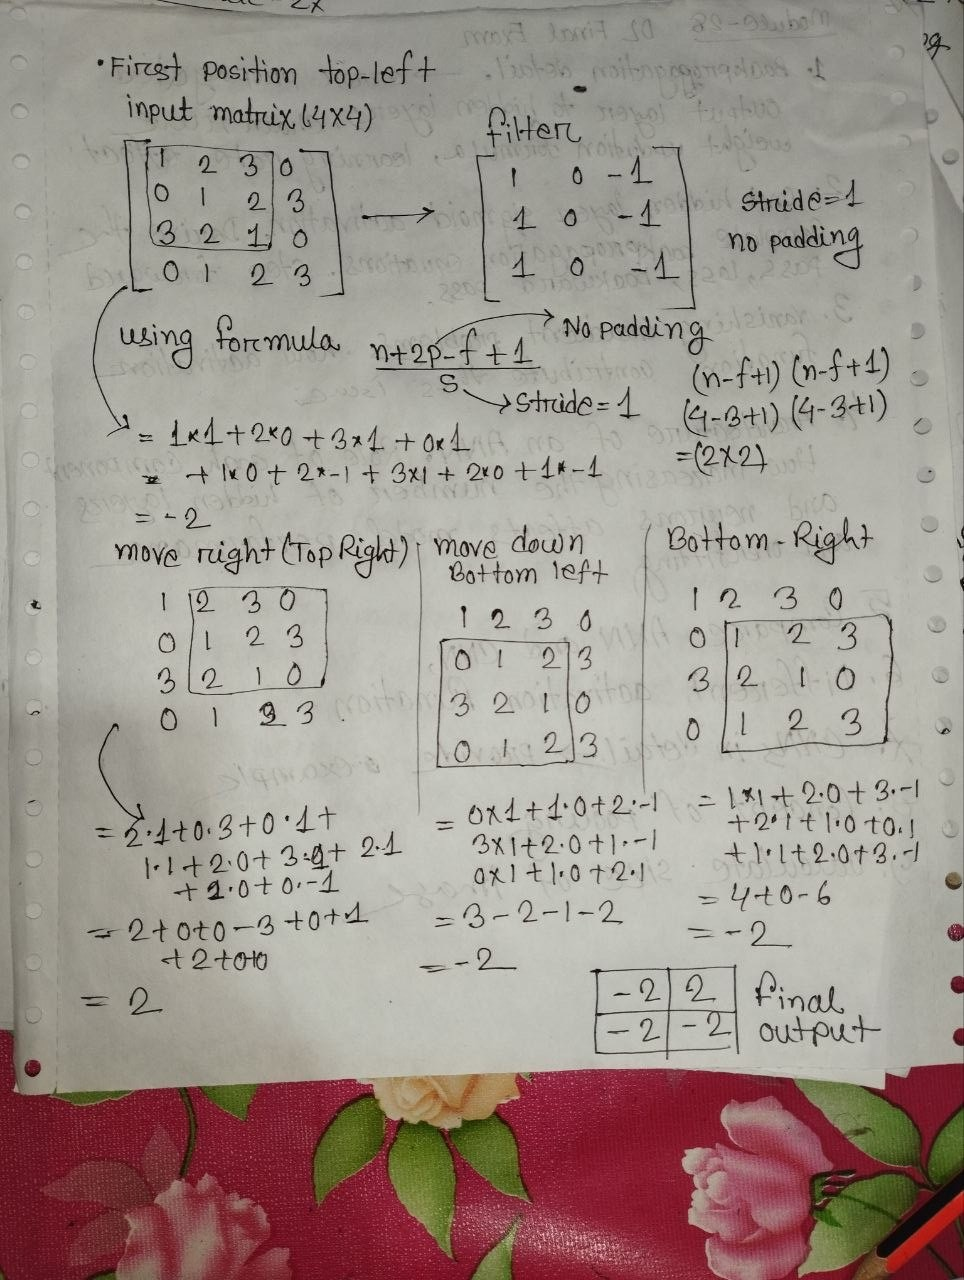

In [5]:
from IPython.display import Image, display

display(Image(filename='/content/photo_2026-04-17_22-26-11.jpg'))

# Question 08: [ Marks 10 ]

## Explain the concept of pooling in CNNs. Compare MaxPooling and AveragePooling in terms of operation, advantages, and impact on feature extraction. Discuss how pooling helps in reducing overfitting and computational complexity.

Write Answer 08:

# Pooling in Convolutional Neural Networks (CNNs)

Pooling is a down-sampling operation typically applied after a convolutional layer. Its primary goal is to reduce the spatial dimensions (width and height) of the input volume for the next layer, while retaining the most important information.

---

## 1. Comparison of MaxPooling and AveragePooling

Both operations use a sliding window (e.g., 2x2) and a stride to process the feature map, but their logic for selecting the output value differs.

| Feature | MaxPooling | AveragePooling |
| :--- | :--- | :--- |
| **Operation** | Selects the **maximum value** from the region covered by the filter. | Calculates the **average value** of all pixels in the region. |
| **Logic** | Captures the most prominent features (edges, textures) that "fire" the most. | Captures a smooth, generalized version of the features. |
| **Advantages** | Very effective at discarding noise and identifying sharp features. | Preserves more background information; smoother transitions. |
| **Disadvantages** | Discards 75% of the data (in 2x2 pooling), potentially losing subtle details. | Can dilute the importance of strong features by averaging them with low values. |



---

## 2. Impact on Feature Extraction

* **Translation Invariance:** Pooling helps the network become invariant to small translations. If a feature (like an eye) shifts by a few pixels, the MaxPool value for that region will likely remain the same, helping the model recognize the object regardless of its exact position.
* **Feature Selection:** MaxPooling acts as a noise suppressant. By picking only the highest activation, it ensures that only the most relevant "signals" are passed deeper into the network.

---

## 3. Benefits of Pooling

### A. Reducing Computational Complexity
By reducing the spatial resolution of the feature maps, pooling significantly decreases the number of parameters and calculations required in subsequent layers.
* *Example:* A 2x2 pooling with a stride of 2 reduces the number of pixels by **75%**. This leads to faster training and lower memory usage.

### B. Reducing Overfitting
Overfitting occurs when a model learns the specific noise or training details too closely. Pooling helps mitigate this by:
* **Summarizing Features:** Instead of looking at every exact pixel location, the model looks at broader regions.
* **Generalization:** By providing an abstracted/abstract version of the features, the model is forced to learn more general patterns that are useful for unseen data.

---

## 4. Mathematical Example (2x2 MaxPool, Stride 2)

**Input Matrix (4x4):**
$$\begin{bmatrix} 12 & 20 & 30 & 0 \\ 8 & 12 & 2 & 0 \\ 34 & 70 & 37 & 4 \\ 112 & 100 & 25 & 12 \end{bmatrix}$$

**MaxPool Output (2x2):**
* Top-left quadrant: $\max(12, 20, 8, 12) = 20$
* Top-right quadrant: $\max(30, 0, 2, 0) = 30$
* Bottom-left quadrant: $\max(34, 70, 112, 100) = 112$
* Bottom-right quadrant: $\max(37, 4, 25, 12) = 37$

**Result:**
$$\begin{bmatrix} 20 & 30 \\ 112 & 37 \end{bmatrix}$$

# Question 09: [ Marks 10 ]

## Given an input image of size 128×128×3, explain step-by-step how the dimensions change after multiple convolution and pooling layers. Clearly show calculations for output size after each layer using appropriate formulas.

# Write Answer 09:

# Step-by-Step Spatial Dimension Analysis in CNNs

To calculate the output size of a layer, we use the following universal formula:
$$OutputSize = \frac{(InputSize - FilterSize + 2 \times Padding)}{Stride} + 1$$

Let the initial input be an image of size **128 x 128 x 3** (Height x Width x Channels).

---

## Layer 1: Convolutional Layer (Conv1)
* **Parameters:** 32 filters, Filter size = 3x3, Stride = 1, Padding = 1.
* **Calculation:**
    * Height/Width: $\frac{(128 - 3 + 2 \times 1)}{1} + 1 = \frac{127}{1} + 1 = 128$
    * Depth: The number of filters becomes the new depth (32).
* **Output Size:** **128 x 128 x 32**

---

## Layer 2: Max Pooling Layer (Pool1)
* **Parameters:** Filter size = 2x2, Stride = 2.
* **Calculation:**
    * Height/Width: $\frac{(128 - 2)}{2} + 1 = \frac{126}{2} + 1 = 63 + 1 = 64$
    * Depth: Pooling does not change the number of channels (remains 32).
* **Output Size:** **64 x 64 x 32**

---

## Layer 3: Convolutional Layer (Conv2)
* **Parameters:** 64 filters, Filter size = 5x5, Stride = 1, Padding = 0.
* **Calculation:**
    * Height/Width: $\frac{(64 - 5 + 0)}{1} + 1 = 59 + 1 = 60$
    * Depth: New depth is 64 (number of filters).
* **Output Size:** **60 x 60 x 64**

---

## Layer 4: Max Pooling Layer (Pool2)
* **Parameters:** Filter size = 2x2, Stride = 2.
* **Calculation:**
    * Height/Width: $\frac{(60 - 2)}{2} + 1 = \frac{58}{2} + 1 = 29 + 1 = 30$
    * Depth: Remains 64.
* **Output Size:** **30 x 30 x 64**

---

## Layer 5: Flattening
Before passing data to a Fully Connected (Dense) layer, the 3D tensor must be flattened into a 1D vector.
* **Calculation:** $30 \times 30 \times 64 = 57,600$
* **Output Size:** **1 x 57,600**

---

## Summary Table

| Layer | Input Size | Filter/Params | Output Size |
| :--- | :--- | :--- | :--- |
| **Input** | 128x128x3 | - | 128x128x3 |
| **Conv1** | 128x128x3 | 3x3, Stride 1, Pad 1 | 128x128x32 |
| **Pool1** | 128x128x32 | 2x2, Stride 2 | 64x64x32 |
| **Conv2** | 64x64x32 | 5x5, Stride 1, Pad 0 | 60x60x64 |
| **Pool2** | 60x60x64 | 2x2, Stride 2 | 30x30x64 |
| **Flatten**| 30x30x64 | - | 57,600 |

# Question 10: [ Marks 20 ]

## Design and implement a deep Convolutional Neural Network (CNN) for a multi-class image classification problem using PyTorch. The network should consist of four convolutional blocks, where each block includes two convolution layers followed by activation and normalization, and a pooling layer at the end. The number of filters should increase progressively across blocks. After the convolutional part, flatten the feature maps and connect them to fully connected layers with dropout for regularization, and produce final outputs corresponding to K classes. Also explain the role of each part of the network in detail.

# Write Answer 10:

1. CNN Architecture (4 Convolutional Blocks)

We design a deep CNN with:

4 Conv blocks
* Each block = (Conv → ReLU → BatchNorm → Conv → ReLU → BatchNorm → MaxPool)
* Filters increase progressively
* Fully connected layers + Dropout
* Final output = K classes

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepCNN, self).__init__()

        # ---------------- Block 1 ----------------
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ---------------- Block 2 ----------------
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ---------------- Block 3 ----------------
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ---------------- Block 4 ----------------
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = x.view(x.size(0), -1)   # flatten
        x = self.fc(x)

        return x


In [2]:
#Loss Function (for training)
criterion = nn.CrossEntropyLoss()

In [3]:
import torch

# model create
model = DeepCNN(num_classes=10)

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# loss function
criterion = nn.CrossEntropyLoss()

3. Input/Output Flow Example

If input image size = 128×128×3

| Stage     | Output Size |
| --------- | ----------- |
| Input     | 128×128×3   |
| Block1    | 64×64×32    |
| Block2    | 32×32×64    |
| Block3    | 16×16×128   |
| Block4    | 8×8×256     |
| Flatten   | 16384       |
| FC Output | K classes   |



4. Role of Each Component
(1) Convolution Layers
* Extract spatial features like edges, textures, shapes
* Deeper layers learn complex patterns (eyes, objects, etc.)
* Increasing filters (32 → 64 → 128 → 256) helps learn richer features

(2) ReLU Activation
* Adds non-linearity
* Helps model learn complex patterns
* Prevents linear behavior of deep networks

(3) Batch Normalization
* Normalizes activations
* Speeds up training
* Reduces internal covariate shift
* Improves stability and convergence

(4) MaxPooling
* Reduces spatial size (downsampling)
* Removes less important details
* Reduces computation
* Helps achieve translation invariance

(5) Fully Connected Layers
* Convert extracted features into class predictions
* Combine all learned features globally

(6) Dropout
* Randomly drops neurons during training
* Prevents overfitting
* Improves generalization

(7) Final Layer
* Outputs K values (logits)
* Each value corresponds to a class score